In [2]:
import numpy as np
import scipy
import pandas
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
sns.set_context('notebook')
import h5py
import allel
import pandas as pd
import zarr

/home/usriniva/anaconda3/envs/zarr-clean/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


In [14]:
vcf_path='/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/depth_allelebal/vcfs/Pf3D7_dep10_90x_AB0.9_qcpass_White_Allchr_combined_filtered_filtered.vcf.gz'

In [28]:
import pandas as pd

# File paths
depth_file = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/Subset_gVCFs/depth_filtered_individuals.txt'
miss_file = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/Subset_gVCFs/missingness_filtered_individuals.txt'
outdir = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/SMC/Maesot_in_out/Inputs/Trial_20inds_forMissingness_depth/cohort_vcf/Subset_gVCFs'

import pandas as pd

# Assuming depth and miss are already loaded as pandas DataFrames

# Remove duplicates in both 'depth' and 'miss' based on 'Individual' and 'Chromosome'
depth_distinct = depth.drop_duplicates(subset=['Individual', 'Chromosome'])
miss_distinct = miss.drop_duplicates(subset=['Individual', 'Chromosome'])

# Perform the left join
Depth30_inds_top3 = pd.merge(depth_distinct, miss_distinct, on=['Individual', 'Chromosome'], how='left')

# Group by 'Chromosome', then sort by 'Missing_Percentage', and select the top 3 rows within each group
Depth30_inds_top3 = (Depth30_inds_top3
                     .sort_values(by=['Chromosome', 'Missing_Percentage'])  # Sort by Missing_Percentage within each Chromosome
                     .groupby('Chromosome', group_keys=False)  # Group by Chromosome, without adding extra index levels
                     .apply(lambda group: group.head(3)))  # Select the top 3 individuals for each Chromosome

# Optionally, view the result
print(Depth30_inds_top3)





    Individual Chromosome    Depth  Missing_Sites  Missing_Count  \
6     PD0518-C      chr01  61.4206         640851          50938   
5     PD0516-C      chr01  56.2744         640851          53266   
1     PD0483-C      chr01  57.7712         640851          58312   
18    PD0516-C      chr02  60.6032         947102          51033   
16    PD0503-C      chr02  84.3130         947102          55542   
13    PD0481-C      chr02  79.8378         947102          56330   
32    PD0518-C      chr03  69.2550        1067971          48573   
31    PD0516-C      chr03  63.4780        1067971          49323   
38    PD0571-C      chr03  60.9450        1067971          53192   
48    PD0518-C      chr04  66.8441        1200490         121474   
47    PD0516-C      chr04  60.1294        1200490         123313   
42    PD0481-C      chr04  80.8190        1200490         126866   
63    PD0518-C      chr05  72.2202        1343557          42612   
62    PD0516-C      chr05  65.0189        134355

/tmp/ipykernel_3044115/688711046.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  Depth30_inds_top3 = (Depth30_inds_top3


In [ ]:
# Group by Chromosome, sort by Missing_Percentage (ascending), and select the top 3 individuals for each Chromosome
Depth30_inds_top3 = (
    Depth30_inds
    .sort_values(by=['Chromosome', 'Missing_Percentage'])  # Sort by Chromosome and Missing_Percentage
    .groupby('Chromosome')  # Group by Chromosome
    .head(3)  # Take top 3 rows per Chromosome (after sorting)
    .reset_index(drop=True)  # Reset index to clean up
)


In [ ]:

# Ensure the output directory exists
import os
if not os.path.exists(outdir):
    os.makedirs(outdir)

# Save the result to a tab-delimited file
output_file = os.path.join(outdir, 'top_3_individuals_per_chromosome.txt')
Depth30_inds_top3.to_csv(output_file, sep='\t', index=False)





    Individual Chromosome    Depth  Missing_Sites  Missing_Count  \
0     PD0481-C      chr01  69.4476         640851          65099   
1     PD0481-C      chr01  69.4476         640851          65099   
2     PD0483-C      chr01  57.7712         640851          58312   
3     PD0483-C      chr01  57.7712         640851          58312   
4     PD0496-C      chr01  67.4521         640851          59010   
..         ...        ...      ...            ...            ...   
835   PD0571-C      chr14  61.4300        3291936          64864   
836   PD0582-C      chr14  39.0513        3291936          67244   
837   PD0582-C      chr14  39.0513        3291936          67244   
838   PD0586-C      chr14  32.6719        3291936          72105   
839   PD0586-C      chr14  32.6719        3291936          72105   

     Missing_Percentage  
0              0.101582  
1              0.101582  
2              0.090992  
3              0.090992  
4              0.092081  
..                  ...  
8

In [ ]:


zarr_path='/home/usriniva/Desktop/masters/NASmountpoint/Plasmodium_us/Inputs/VCFs/vcf_gz/zarrs/AllChr_ABfilt_2_qcpass_White_combined.zarr'

callset = zarr.open_group(zarr_path, mode='r')
callset.tree()

vcf_path = '/home/usriniva/Desktop/masters/NASmountpoint/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/depth_allelebal/vcfs/new_trial/Pf3D7_dep10_90x_AB0.9_qcpass_White_Allchr_combined_final_filtered.vcf.gz'
zarr_path='/home/usriniva/Desktop/masters/plasmodium/zarrs/AllChr_dep10_90x_AB0.9_white.zarr'

allel.vcf_to_zarr(vcf_path, zarr_path, group='all', fields='*', transformers=allel.ANNTransformer(), overwrite=True)


/
└── All_chr
    ├── calldata
    │   ├── AD (480058, 270, 4) int16
    │   ├── DP (480058, 270) int16
    │   ├── GQ (480058, 270) int8
    │   ├── GT (480058, 270, 2) int8
    │   ├── MIN_DP (480058, 270) int32
    │   ├── PGT (480058, 270) StringDType()
    │   ├── PID (480058, 270) StringDType()
    │   ├── PL (480058, 270, 3) int32
    │   ├── PS (480058, 270) int32
    │   ├── RGQ (480058, 270) int32
    │   └── SB (480058, 270, 4) int32
    ├── samples (270,) StringDType()
    └── variants
        ├── AC (480058, 3) int32
        ├── AF (480058, 3) float32
        ├── ALT (480058, 3) StringDType()
        ├── AN (480058,) int32
        ├── ANN_AA_length (480058,) int32
        ├── ANN_AA_pos (480058,) int32
        ├── ANN_Allele (480058,) StringDType()
        ├── ANN_Annotation (480058,) StringDType()
        ├── ANN_Annotation_Impact (480058,) StringDType()
        ├── ANN_CDS_length (480058,) int32
        ├── ANN_CDS_pos (480058,) int32
        ├── ANN_Distance (480058,) int32
        ├── ANN_Feature_ID (480058,) StringDType()
        ├── ANN_Feature_Type (480058,) StringDType()
        ├── ANN_Gene_ID (480058,) StringDType()
        ├── ANN_Gene_Name (480058,) StringDType()
        ├── ANN_HGVS_c (480058,) StringDType()
        ├── ANN_HGVS_p (480058,) StringDType()
        ├── ANN_Rank (480058,) int8
        ├── ANN_Transcript_BioType (480058,) StringDType()
        ├── ANN_cDNA_length (480058,) int32
        ├── ANN_cDNA_pos (480058,) int32
        ├── AS_BaseQRankSum (480058, 3) float32
        ├── AS_FS (480058, 3) float32
        ├── AS_InbreedingCoeff (480058, 3) float32
        ├── AS_MQ (480058, 3) float32
        ├── AS_MQRankSum (480058, 3) float32
        ├── AS_QD (480058, 3) float32
        ├── AS_ReadPosRankSum (480058, 3) float32
        ├── AS_SOR (480058, 3) float32
        ├── BaseQRankSum (480058,) float32
        ├── CDS (480058,) bool
        ├── CHROM (480058,) StringDType()
        ├── DP (480058,) int32
        ├── DS (480058,) bool
        ├── END (480058,) int32
        ├── ExcessHet (480058,) float32
        ├── FILTER_Apicoplast (480058,) bool
        ├── FILTER_Centromere (480058,) bool
        ├── FILTER_InternalHypervariable (480058,) bool
        ├── FILTER_LowQual (480058,) bool
        ├── FILTER_Low_VQSLOD (480058,) bool
        ├── FILTER_MissingVQSLOD (480058,) bool
        ├── FILTER_Mitochondrion (480058,) bool
        ├── FILTER_PASS (480058,) bool
        ├── FILTER_SubtelomericHypervariable (480058,) bool
        ├── FILTER_SubtelomericRepeat (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.50to99.60 (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.60to99.80 (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.80to99.90 (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.90to99.95 (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.95to100.00 (480058,) bool
        ├── FILTER_VQSRTrancheINDEL99.95to100.00+ (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.50to99.60 (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.60to99.80 (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.80to99.90 (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.90to99.95 (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.95to100.00 (480058,) bool
        ├── FILTER_VQSRTrancheSNP99.95to100.00+ (480058,) bool
        ├── FS (480058,) float32
        ├── ID (480058,) StringDType()
        ├── InbreedingCoeff (480058,) float32
        ├── LOF (480058,) StringDType()
        ├── MLEAC (480058, 3) int32
        ├── MLEAF (480058, 3) float32
        ├── MQ (480058,) float32
        ├── MQRankSum (480058,) float32
        ├── NEGATIVE_TRAIN_SITE (480058,) bool
        ├── NMD (480058,) StringDType()
        ├── POS (480058,) int32
        ├── POSITIVE_TRAIN_SITE (480058,) bool
        ├── QD (480058,) float32
        ├── QUAL (480058,) float32
        ├── RAW_MQandDP (480058, 2) int32
        ├── REF (480058,) StringDType()
        ├── ReadPosRankSum (480058,) float32
        ├── RegionType (48

In [15]:
gt_zarr = callset['All_chr/calldata/GT']
gt_zarr.info
# Load the variants data (assuming callset is defined elsewhere)
variants = allel.VariantChunkedTable(callset['All_chr/variants'])


TypeError: object of type 'Array' has no len()

In [ ]:


# Assuming 'variants' is your ChunkedTableWrapper object
chrom_uniq = np.unique(variants['CHROM'])

chrom_variants = {}
chrom_pos = {}
chrom_gt = {}


calldata =  callset['all/calldata']

list(calldata.keys())

['AD', 'DP', 'GQ', 'GT', 'MIN_DP', 'PGT', 'PID', 'PL', 'PS', 'RGQ', 'SB']

In [9]:
calldata['AD'].shape

(479833, 471, 4)

In [19]:
genotypes = allel.GenotypeChunkedArray(calldata['GT'])
genotypes


<GenotypeChunkedArray shape=(479833, 471, 2) dtype=int8 chunks=(65536, 64, 2)
   nbytes=431.1M cbytes=6.1M cratio=70.2
   compression=blosc compression_opts={'cname': 'lz4', 'clevel': 5, 'shuffle': 1, 'blocksize': 0}
   values=zarr.core.Array>

In [6]:
n_variants = len(variants)
pc_missing = (genotypes.count_missing(axis=0)[:] / n_variants) * 100
pc_het = genotypes.count_het(axis=0)[:] * 100 / n_variants

In [7]:

for chrom in chrom_uniq:
    # Create a boolean mask for the current chromosome
    mask_chrom = variants['CHROM'] == chrom
    
    # Use compress to subset the variants for the current chromosome
    chrom_variants[chrom] = variants.compress(mask_chrom)
    
    # Extract the positions for the current chromosome from the filtered variants
    chrom_pos[chrom] = np.unique(chrom_variants[chrom]['POS'])

    # Subset genotypes for the current chromosome
    chrom_gt[chrom] = genotypes.compress(mask_chrom)

    # Calculate the range of positions for the current chromosome in base pairs
    chrom_range_bp = np.max(chrom_pos[chrom]) - np.min(chrom_pos[chrom])
    
    # Convert the range from base pairs to megabase pairs
    chrom_range_mb = chrom_range_bp / 1_000_000

    # Print the range for the current chromosome in megabase pairs
    print(f"Chromosome {chrom}: Range = {chrom_range_mb:.2f} Mb")


# Now chrom_variants contains the subsets of variants for each chromosome
# and chrom_pos contains the unique positions for each chromosome




Chromosome Pf3D7_01_v3: Range = 0.48 Mb
Chromosome Pf3D7_02_v3: Range = 0.76 Mb
Chromosome Pf3D7_03_v3: Range = 0.93 Mb
Chromosome Pf3D7_04_v3: Range = 1.05 Mb
Chromosome Pf3D7_05_v3: Range = 1.28 Mb
Chromosome Pf3D7_06_v3: Range = 1.22 Mb
Chromosome Pf3D7_07_v3: Range = 1.30 Mb
Chromosome Pf3D7_08_v3: Range = 1.29 Mb
Chromosome Pf3D7_09_v3: Range = 1.39 Mb
Chromosome Pf3D7_10_v3: Range = 1.50 Mb
Chromosome Pf3D7_11_v3: Range = 1.89 Mb
Chromosome Pf3D7_12_v3: Range = 2.10 Mb
Chromosome Pf3D7_13_v3: Range = 2.72 Mb
Chromosome Pf3D7_14_v3: Range = 3.22 Mb


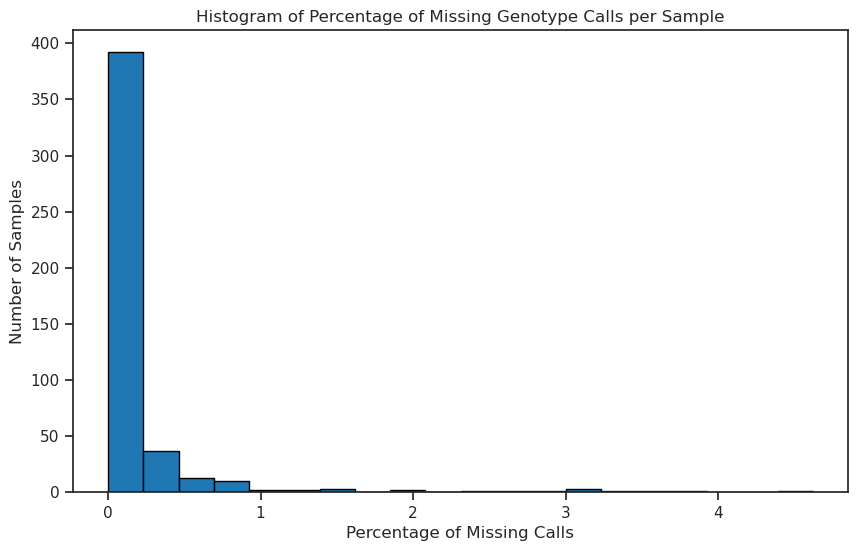

In [8]:
# Create a histogram
plt.figure(figsize=(10, 6))
plt.hist(pc_missing, bins=20, edgecolor='black')
plt.xlabel('Percentage of Missing Calls')
plt.ylabel('Number of Samples')
plt.title('Histogram of Percentage of Missing Genotype Calls per Sample')
plt.show()

In [10]:

samples_p = '/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471_inds_samplemd.txt'
samples = pd.read_csv(samples_p, sep='\t')

samples.SiteCountry.value_counts()

SiteCountry
PreahVihear_Cambodia    82
MaeSot_Thailand         81
Pursat_Cambodia         73
Pailin_Cambodia         71
BinhPhuoc_VietNam       71
Ratanakiri_Cambodia     58
Ranong_Thailand         18
Sisakhet_Thailand       17
Name: count, dtype: int64

In [11]:
def plot_genotype_frequency(pc, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.despine(ax=ax, offset=10)
    left = np.arange(len(pc))
    palette = sns.color_palette()
    pop2color = {'PreahVihear_Cambodia': palette[0], 'MaeSot_Thailand': palette[1],'Pursat_Cambodia' : palette[2],
                 'Pailin_Cambodia': palette[3],'BinhPhuoc_VietNam': palette[4],'Ratanakiri_Cambodia': palette[5],
                 'Ranong_Thailand': palette[6],'Sisakhet_Thailand': palette[7]}
    colors = [pop2color[p] for p in samples.SiteCountry]
    ax.bar(left, pc, color=colors)
    ax.set_xlim(0, len(pc))
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Percent calls')
    ax.set_title(title)
    handles = [mpl.patches.Patch(color=palette[0]),
               mpl.patches.Patch(color=palette[1]),
               mpl.patches.Patch(color=palette[2]),
               mpl.patches.Patch(color=palette[3]),
               mpl.patches.Patch(color=palette[4]),
               mpl.patches.Patch(color=palette[5]),
               mpl.patches.Patch(color=palette[6]),
               mpl.patches.Patch(color=palette[7])
                                 ]
    ax.legend(handles=handles, labels=['PreahVihear_Cambodia', 'MaeSot_Thailand','Pursat_Cambodia',
                                       'Pailin_Cambodia','BinhPhuoc_VietNam','Ratanakiri_Cambodia',
                                       'Ranong_Thailand','Sisakhet_Thailand'], title='Population',
              bbox_to_anchor=(1, 1), loc='upper left')

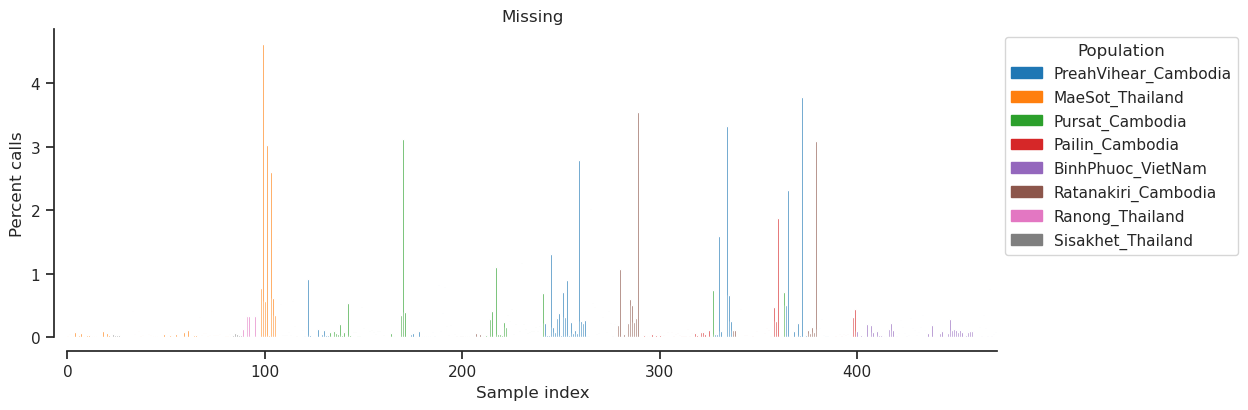

In [12]:
plot_genotype_frequency(pc_missing, 'Missing')

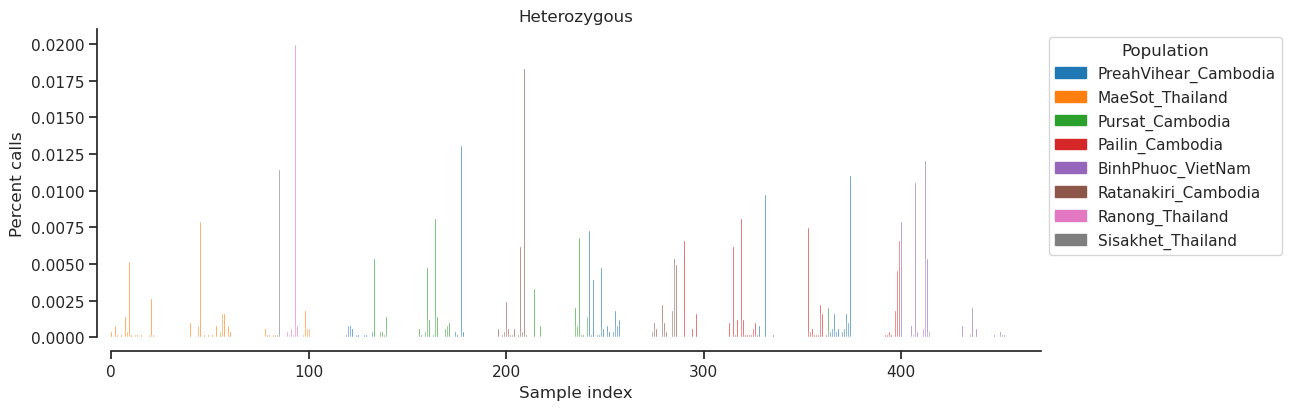

In [13]:
plot_genotype_frequency(pc_het, 'Heterozygous')

In [62]:
ac = genotypes.count_alleles(axis=0)

/data/proj2/home/students/u.srinivasan/.conda/envs/scikit-allel/lib/python3.9/site-packages/zarr/creation.py:300: UserWarning: ignoring keyword argument 'axis'
  warn(f"ignoring keyword argument {k!r}")


In [57]:

# Function to apply the "5/2 rule"
def filter_heterozygous_sites(genotypes):
    # Calculate allele counts
    ac = genotypes.count_alleles(axis=0)

    # Initialize a list to store indices of heterozygous sites
    het_sites = []

    # Iterate over each variant
    for i in range(genotypes.shape[0]):
        # Get the allele counts for this variant
        ref_count = ac[i, 0]
        alt_count = ac[i, 1]

        # Apply the "5/2 rule"
        if ref_count >= 2 and alt_count >= 2 and (ref_count + alt_count) > 5:
            het_sites.append(i)

    return het_sites

# Get the indices of heterozygous sites
heterozygous_sites = filter_heterozygous_sites(genotypes)

# Output the indices of heterozygous sites
print("Heterozygous sites:", heterozygous_sites)

Heterozygous sites: [0, 16, 26, 28, 39, 40, 45, 53, 61, 77, 81, 86, 91, 98, 101, 109, 110, 119, 122, 129, 141, 142, 143, 150, 153, 195, 212, 246, 269, 287, 297, 311, 325, 338, 377, 410, 419, 432, 440, 446, 477, 480, 482, 491, 515, 548, 553, 559, 565, 589, 616, 621, 645, 651, 652, 653, 668, 691, 698, 712, 716, 720, 730, 736, 746, 753, 776, 789, 799, 800, 812, 815, 853, 886, 902, 916, 928, 934, 940, 957, 967, 968, 993, 1020, 1021, 1045, 1058, 1059, 1066, 1101, 1138, 1190, 1192, 1214, 1217, 1221, 1241, 1250, 1258, 1263, 1271, 1291, 1312, 1319, 1324, 1345, 1351, 1356, 1363, 1381, 1399, 1420, 1465, 1467, 1483, 1496, 1501, 1522, 1563, 1568, 1579, 1581, 1583, 1589, 1608, 1609, 1611, 1624, 1627, 1675, 1688, 1695, 1697, 1699, 1714, 1716, 1722, 1746, 1757, 1776, 1777, 1778, 1787, 1795, 1803, 1821, 1828, 1838, 1852, 1857, 1892, 1894, 1899, 1917, 1935, 1953, 1996, 2003, 2014, 2019, 2024, 2029, 2030, 2046, 2056, 2057, 2061, 2070, 2082, 2087, 2088, 2092, 2095, 2096, 2099, 2102, 2103, 2104, 2105, 210

In [61]:
het_sites_df = pd.DataFrame(heterozygous_sites, columns=['Heterozygous Site Index'])


# Save the DataFrame to a CSV file
output_csv = 'heterozygous_sites.csv'
het_sites_df.to_csv(output_csv, index=False)

In [8]:
# Load the variants data (assuming callset is defined elsewhere)
variants_1 = allel.VariantChunkedTable(callset['oldbal/variants'], 
                                     names=['POS', 'CHROM', 'numalt', 'REF', 'ALT', 'DP', 'MQ', 'QD'],
                                     index='POS')


print(variants_1.shape)

(4138,)


In [28]:
# Load the variants data (assuming callset is defined elsewhere)
variants_2 = allel.VariantChunkedTable(callset['newbal/variants'], 
                                     names=['POS', 'CHROM', 'numalt', 'REF', 'ALT', 'DP', 'MQ', 'QD'],
                                     index='POS')

print(variants_2.shape)                                     

(5065,)


In [14]:
variants_2

,POS,CHROM,numalt,REF,ALT,DP,MQ,QD
0,1082178,Pf3D7_13_v3,1,C,['T' '' ''],268,57.54,nan
1,1082196,Pf3D7_13_v3,1,T,['C' '' ''],255,57.41,nan


In [59]:
callset['newbal/calldata/AD'][:,1]

array([[ 75,   7,  -1,  -1],
       [ 72,   7,  -1,  -1],
       [ 68,   7,  -1,  -1],
       ...,
       [  0, 265,  -1,  -1],
       [  0, 262,  -1,  -1],
       [262,   0,  -1,  -1]], dtype=int16)

In [10]:
genotypes = allel.GenotypeChunkedArray(callset['all/calldata/GT'])
genotypes

<GenotypeChunkedArray shape=(3785, 3, 2) dtype=int8 chunks=(65536, 3, 2)
   nbytes=22.2K cbytes=10.1K cratio=2.2
   compression=blosc compression_opts={'cname': 'lz4', 'clevel': 5, 'shuffle': 1, 'blocksize': 0}
   values=zarr.core.Array>

In [4]:
calldata =  callset['all/calldata']
list(calldata.keys())

['AD', 'DP', 'GQ', 'GT', 'PGT', 'PID', 'PL', 'PS', 'RGQ', 'SB']

In [53]:
genotypes = allel.GenotypeChunkedArray(callset['newbal/calldata/GT'])
genotypes
n_variants = len(variants_2)
pc_het = genotypes.count_het(axis=0)[:] * 100 / n_variants

In [11]:
het_calls=genotypes.is_het()[:]
het_gt = genotypes.compress(het_calls[:, 0], axis=0)
het_var = variants.compress(het_calls[:, 0], axis=0)


In [47]:
def plot_variant_hist(variants,f, bins=30):
    x = variants[f][:]
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.despine(ax=ax, offset=10)
    ax.hist(x, bins=bins)
    ax.set_xlabel(f)
    ax.set_ylabel('No. variants')
    ax.set_title('Variant %s distribution' % f)

In [23]:
het_var['DP'][:]

array([ 54,  95, 123, ..., 360, 413, 183], dtype=int32)

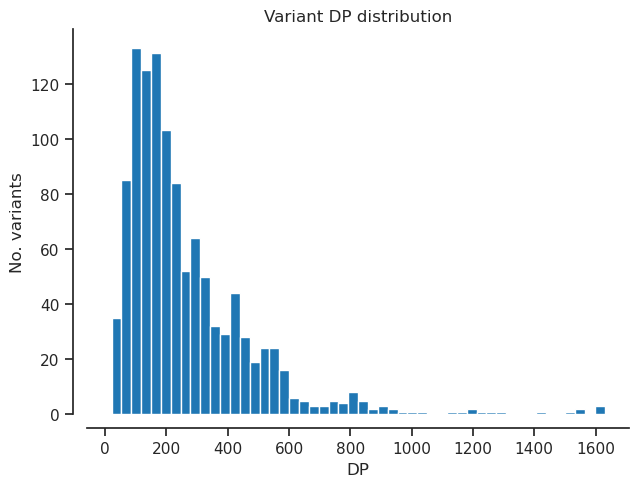

In [13]:
plot_variant_hist(het_var,'DP', bins=50)

In [20]:
ac=genotypes.count_alleles()

print(ac[:])

7 1 0 0
2 6 0 0
2 6 0 0
...
7 1 0 0
7 1 0 0
7 1 0 0



Text(0.5, 1.0, 'Variant distribution')

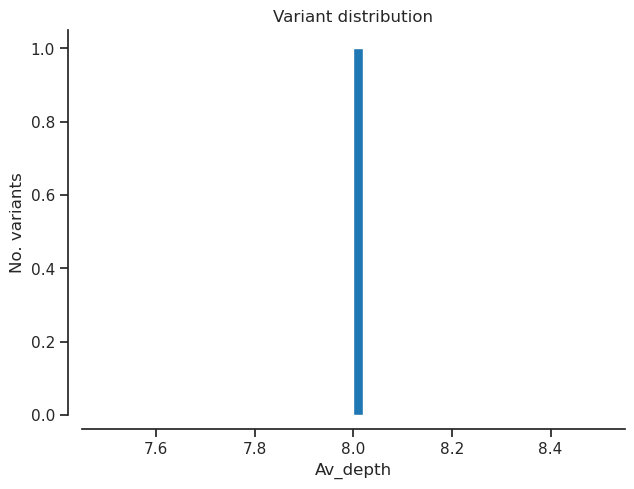

In [14]:


fig, ax = plt.subplots(figsize=(7, 5))
sns.despine(ax=ax, offset=10)
ax.hist(avdp_persite, bins=50)
ax.set_xlabel('Av_depth')
ax.set_ylabel('No. variants')
ax.set_title('Variant distribution' )


Text(0.5, 1.0, 'Percentage of Heterozygous Calls per Sample')

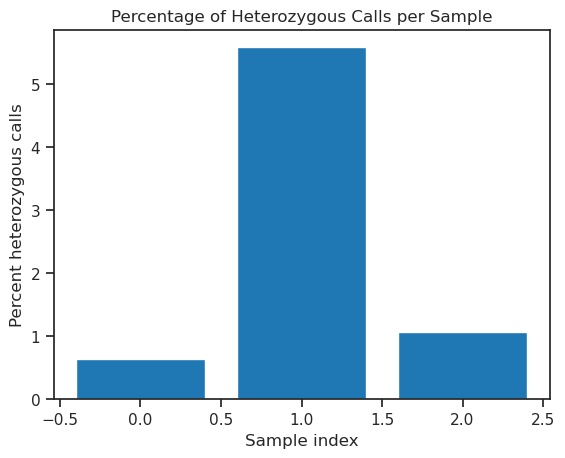

In [54]:
# Create an array for the x-axis positions
left = np.arange(len(pc_het))

# Create the bar plot
plt.bar(left, pc_het)

# Set the labels for the x and y axes
plt.xlabel('Sample index')
plt.ylabel('Percent heterozygous calls')

# Set the title of the plot
plt.title('Percentage of Heterozygous Calls per Sample')


In [26]:
len(pc_het)
pc_het = genotypes.count_het(axis=1)[:] * 100 / 4
print(pc_het)

[25.  0.  0. ... 25. 25. 25.]


In [23]:
len(pc_het)

6255

Text(0, 0.5, 'Percent heterozygous calls')

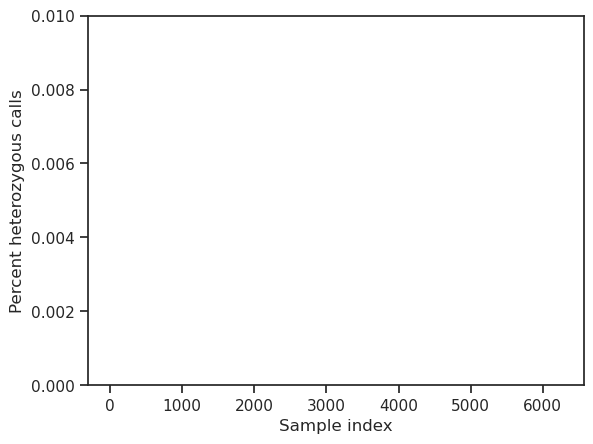

In [27]:
# Create an array for the x-axis positions
left = np.arange(len(pc_het))

# Create the bar plot
plt.bar(left, pc_het)
plt.ylim(0,0.01)
# Set the labels for the x and y axes
plt.xlabel('Sample index')
plt.ylabel('Percent heterozygous calls')
